In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from pyfrechet.metric_spaces import MetricData, Sphere
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pyfrechet.metric_spaces import MetricData, Sphere
import cloudpickle
import base64
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed
from scipy.stats import vonmises_fisher, vonmises_line

INFO: Using numpy backend


## Functions

In [2]:
def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'kappa', 'OOB_quantile', 'forest'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_sphere'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        forest = result['forest']
        oob_quantile = np.percentile(forest.oob_errors(), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'kappa': file.split('_')[3][5:],
            'forest': [forest],
            'OOB_quantile': [oob_quantile],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['kappa'] = coverage_df.kappa.astype('category')
    return coverage_df


# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

Prediction balls

In [3]:
# Define confidence levels
M = Sphere(2)
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
pb_coverage_df=pb_coverage_results()
pb_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

,sample_index,train_size,kappa,OOB_quantile,forest
0,339,200,50,"[0.41928123850146876, 0.3698619610634871, 0.29...","BaggedRegressor(bootstrap_fraction=1, bootstra..."
1,452,100,200,"[0.22376592762247913, 0.1647918582377614, 0.14...","BaggedRegressor(bootstrap_fraction=1, bootstra..."
2,440,500,200,"[0.22155042984087625, 0.17373422395251084, 0.1...","BaggedRegressor(bootstrap_fraction=1, bootstra..."
3,305,50,50,"[0.38757233104291516, 0.3500957805772132, 0.32...","BaggedRegressor(bootstrap_fraction=1, bootstra..."
4,494,200,50,"[0.3898467138422756, 0.34420546210854863, 0.31...","BaggedRegressor(bootstrap_fraction=1, bootstra..."


# TYPE I

In [4]:
kappas = np.array([100])

MC = 500
n_estimations = 50

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

In [12]:
MC = 500
n_estimations = 50

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_i = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '500': zeros_init}
    }

# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for kappa in [50, 200]:
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)

            theta = vonmises_line(kappa = 1).rvs(MC) + np.pi
            theta, new_ys = simulate_data(kappa = kappa, mu = mu, theta_samples = theta)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                # Retrieve the data           
                new_y = MetricData(M, new_ys[i])
                new_theta = theta[i].reshape(-1, 1)
                pb_new_pred = pb_ln['forest'].predict(new_theta)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']))
                i += 1
            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_i['kappa_'+str(kappa)][str(N)] = np.copy(pb_cov)

In [28]:
import numpy as np
from scipy.stats import vonmises_line
variables = vonmises_line(kappa = 1).rvs(1000000) + np.pi
# estimate te 0.25 quantile
quantile = np.percentile(variables, 25)
quantile

2.33220238398948

In [15]:
for kappa in [50, 200]:    
        for N in [50, 100, 200, 500]:
            print(f"kappa = {kappa}, N = {N}, mean of Type I coverage estimates: ", np.mean(pb_diccionario_i['kappa_'+str(kappa)][str(N)], axis = 0)) 
            print(f"kappa = {kappa}, N = {N}, standard deviation of Type I coverage estimates: ", np.sqrt(np.var(pb_diccionario_i['kappa_'+str(kappa)][str(N)], axis = 0))  )    

kappa = 50, N = 50, mean of Type I coverage estimates:  [1.      0.98356 0.96372]
kappa = 50, N = 50, standard deviation of Type I coverage estimates:  [0.         0.00581433 0.00745128]
kappa = 50, N = 100, mean of Type I coverage estimates:  [1.      0.98464 0.965  ]
kappa = 50, N = 100, standard deviation of Type I coverage estimates:  [0.         0.00549094 0.0079019 ]
kappa = 50, N = 200, mean of Type I coverage estimates:  [1.      0.98636 0.9708 ]
kappa = 50, N = 200, standard deviation of Type I coverage estimates:  [0.         0.00487754 0.00681175]
kappa = 50, N = 500, mean of Type I coverage estimates:  [1.      0.98764 0.97184]
kappa = 50, N = 500, standard deviation of Type I coverage estimates:  [0.         0.00487754 0.00699531]
kappa = 200, N = 50, mean of Type I coverage estimates:  [1.      0.98112 0.96272]
kappa = 200, N = 50, standard deviation of Type I coverage estimates:  [0.         0.00641448 0.00994995]
kappa = 200, N = 100, mean of Type I coverage estimates: 

Prediction balls

In [23]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level          0.01          0.05           0.1
kappa N                                                     
50    50            98.34 (0.58)  94.44 (0.83)  88.27 (1.24)
      100           98.27 (0.57)  94.46 (0.87)  89.31 (1.36)
      200           98.41 (0.54)  94.52 (1.03)  89.51 (1.28)
      500           98.89 (0.46)  94.96 (0.97)  89.88 (1.19)
200   50            98.68 (0.47)  94.83 (0.89)  88.90 (1.29)
      100           98.36 (0.58)  94.44 (1.15)  89.53 (1.40)
      200           98.61 (0.57)  94.56 (0.93)  89.70 (1.25)
      500           98.87 (0.50)  95.04 (0.97)  89.81 (1.24)

In [15]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/2912561022.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [16]:
print(latex)

\begin{table}
\caption{Type I error}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 98.34 (0.58) & 94.44 (0.83) & 88.27 (1.24) \\
\textbf{} & \textbf{100} & 98.27 (0.57) & 94.46 (0.87) & 89.31 (1.36) \\
\textbf{} & \textbf{200} & 98.41 (0.54) & 94.52 (1.03) & 89.51 (1.28) \\
\textbf{} & \textbf{500} & 98.89 (0.46) & 94.96 (0.97) & 89.88 (1.19) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 98.68 (0.47) & 94.83 (0.89) & 88.90 (1.29) \\
\textbf{} & \textbf{100} & 98.36 (0.58) & 94.44 (1.15) & 89.53 (1.40) \\
\textbf{} & \textbf{200} & 98.61 (0.57) & 94.56 (0.93) & 89.70 (1.25) \\
\textbf{} & \textbf{500} & 98.87 (0.50) & 95.04 (0.97) & 89.81 (1.24) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# TYPE II

In [17]:
from joblib import Parallel, delayed

pb_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500

np.random.seed(1000)

def compute_coverage(i, ln, MC, mu):
    # Generate observations to estimate the probability
    
    theta_samples = np.array([vonmises_line(kappa = 1).rvs(MC) + np.pi]).reshape(-1, 1)
    new_X, new_y = simulate_data(kappa=float(ln['kappa']), theta_samples=theta_samples, mu=mu)

    new_pred = ln['forest'].predict(new_X.reshape(-1, 1))
    coverage = np.sum(M.d(MetricData(M, new_y), new_pred) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis=0) / MC
    print(i)
    return i, coverage

# Run in parallel
results = Parallel(n_jobs=8)(delayed(compute_coverage)(i, ln, MC, mu) for i, ln in pb_coverage_df.iterrows())

# Store results
for i, coverage in results:
    pb_coverage_df.at[i, 'II_coverage'] = coverage

1
0
3
5
6
7
4
2
8
9
10
11
13
15
12
16
18
17
14
21
22
20
19
25
23
24
27
26
29
28
30
33
32
31
34
37
35
36
38
39
42
40
44
43
41
46
45
47
49
52
51
48
54
53
50
56
55
57
58
59
60
61
63
64
62
65
66
69
68
70
71
72
67
74
73
75
77
76
78
80
79
82
81
85
83
84
86
87
91
90
88
89
92
94
95
99
96
93
98
97
102
101
104
100
103
107
105
109
106
108
110
112
111
115
114
113
117
116
118
120
119
121
123
122
124
126
125
129
127
128
130
131
132
133
135
134
137
139
136
138
140
142
144
143
141
147
146
148
150
145
149
152
151
153
157
155
158
156
154
159
162
161
160
163
164
165
168
166
169
167
171
173
170
172
175
177
178
179
180
176
174
181
182
184
183
186
187
189
185
188
190
193
191
195
192
196
194
198
200
199
201
197
203
205
204
202
208
209
207
206
210
212
214
211
213
218
219
217
216
221
215
222
220
224
226
223
228
225
227
229
231
230
232
235
236
233
237
234
238
241
239
242
240
245
247
244
246
243
248
249
250
251
254
252
253
256
255
257
258
261
259
263
260
262
265
264
266
268
267
270
269
273
272
274
277
271
275
27

### KAPPA 50

In [124]:
ii_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

ii_pb_coverage_df_kappa_50_alpha_01['II_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['II_coverage'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_50_alpha_05['II_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['II_coverage'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_50_alpha_1['II_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['II_coverage'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_50_alpha_01.head()
ii_pb_coverage_df_kappa_50_alpha_05.head()
ii_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,II_coverage,IV_coverage
0,339,200,50,0.355943,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.936,"[0.992, 0.984, 0.96]"
3,305,50,50,0.345324,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.870,"[0.652, 0.584, 0.372]"
4,494,200,50,0.354906,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.924,"[0.998, 0.986, 0.952]"
5,103,100,50,0.354269,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.904,"[0.99, 0.974, 0.934]"
6,49,50,50,0.393954,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.924,"[1.0, 0.982, 0.86]"


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3995021474.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


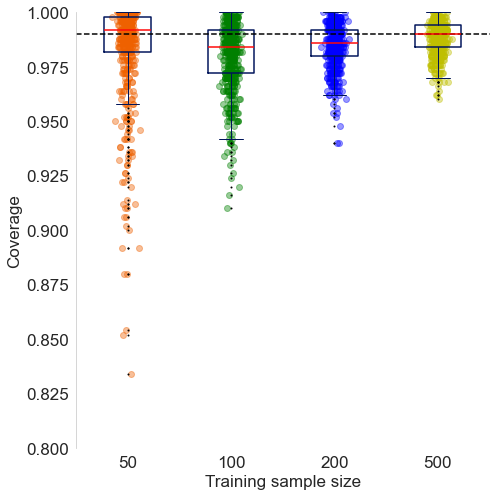

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3995021474.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


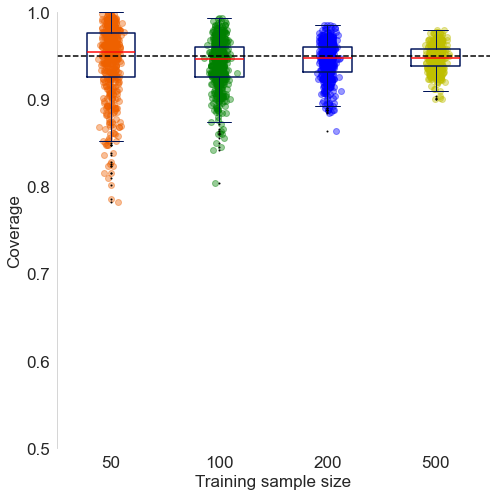

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3995021474.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


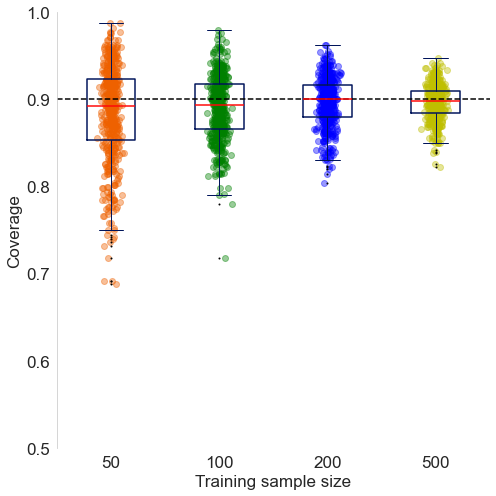

In [79]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_kappa_50_alpha_01, ii_pb_coverage_df_kappa_50_alpha_05, ii_pb_coverage_df_kappa_50_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_50_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [149]:
ii_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

ii_pb_coverage_df_kappa_200_alpha_01['II_coverage'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['II_coverage'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_200_alpha_05['II_coverage'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['II_coverage'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_200_alpha_1['II_coverage'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['II_coverage'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_200_alpha_01.head()
ii_pb_coverage_df_kappa_200_alpha_05.head()
ii_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,II_coverage,IV_coverage
1,452,100,200,0.179382,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.832,"[1.0, 0.998, 0.952]"
2,440,500,200,0.170186,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.898,"[0.994, 0.96, 0.904]"
9,90,500,200,0.171167,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.918,"[0.978, 0.952, 0.874]"
11,35,100,200,0.193350,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.882,"[1.0, 0.99, 0.958]"
12,173,500,200,0.153221,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,0.888,"[0.988, 0.916, 0.864]"


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/2134326729.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


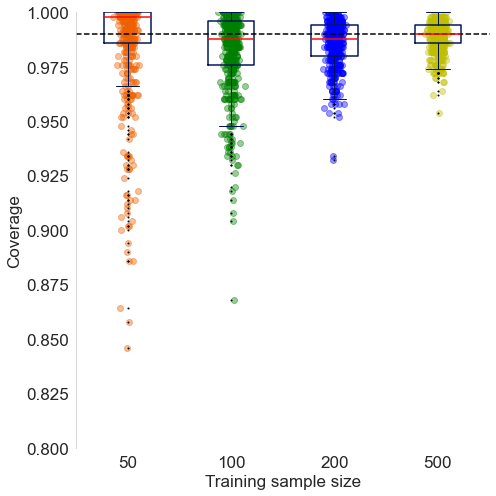

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/2134326729.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


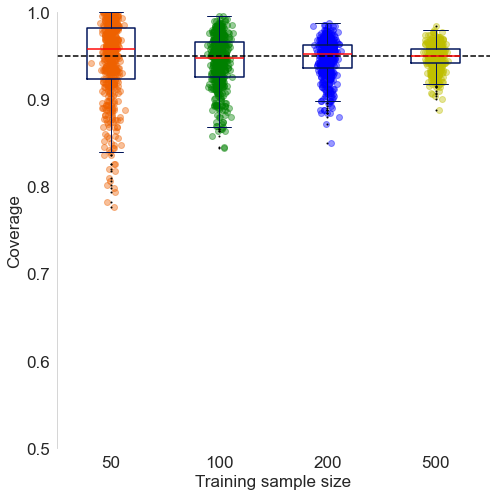

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/2134326729.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


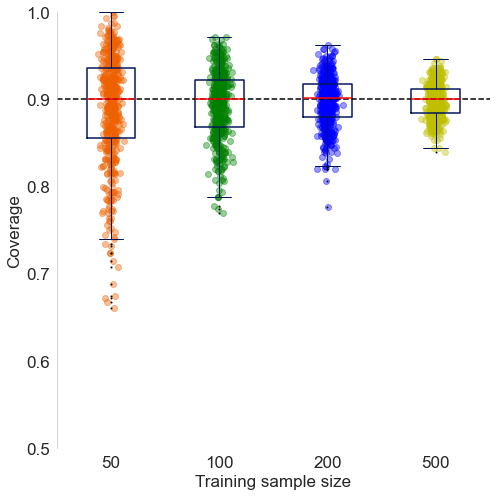

In [81]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_kappa_200_alpha_01, ii_pb_coverage_df_kappa_200_alpha_05, ii_pb_coverage_df_kappa_200_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_200_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

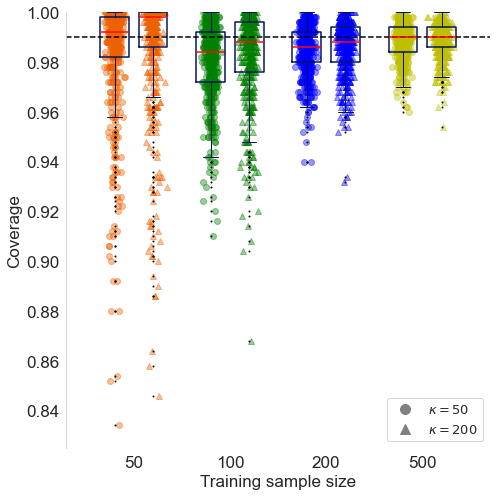

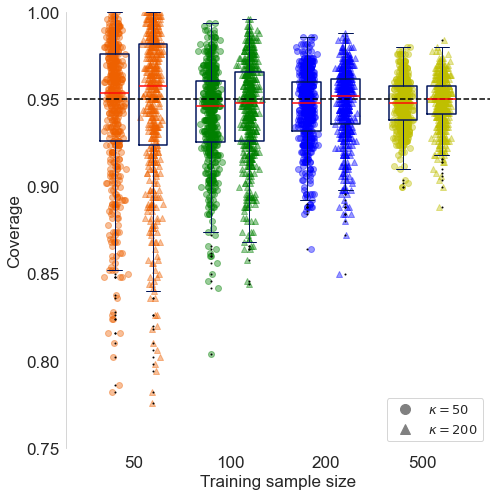

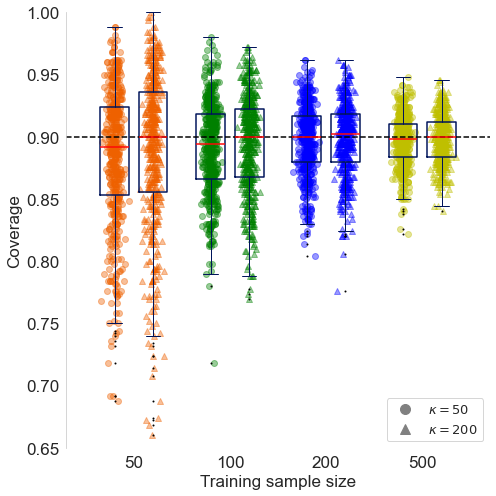

In [146]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, kappa_200_data, alpha_level in zip(
    [ii_pb_coverage_df_kappa_50_alpha_01, ii_pb_coverage_df_kappa_50_alpha_05, ii_pb_coverage_df_kappa_50_alpha_1], 
    [ii_pb_coverage_df_kappa_200_alpha_01, ii_pb_coverage_df_kappa_200_alpha_05, ii_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['II_coverage'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['II_coverage'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1)
    else:
        ax.set_ylim(0.65, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_50_200_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

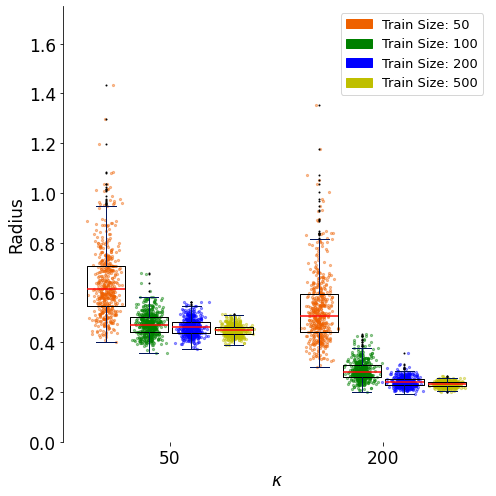

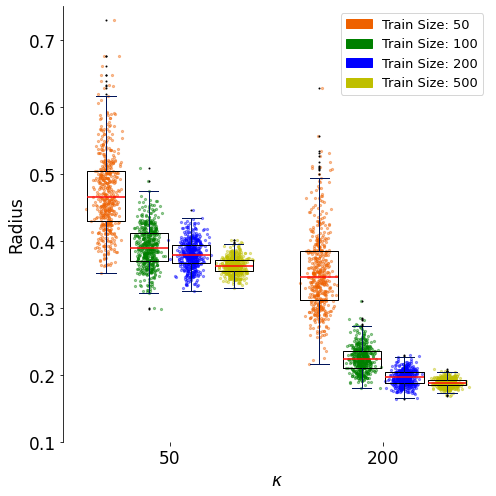

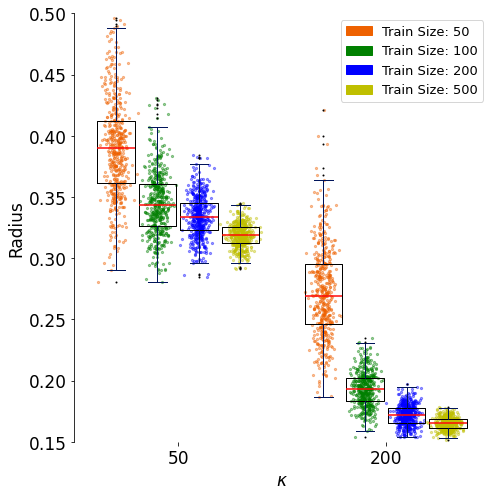

In [29]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    kappas = coverage_df['kappa'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['kappa'] == kappa) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for kappa in kappas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(kappas))],
        labels=kappas
    )
    ax.set_xlim(0, len(kappas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0, 1.75)
    elif alpha_level == 0.05:
        ax.set_ylim(0.1, 0.75)
    else:
        ax.set_ylim(0.15, 0.5)
        
    ax.set_xlabel(r'$\kappa$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_sphere/pb_sphere_radius_vs_kappa' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [25]:
MC = 500
n_estimations = 50

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '500': zeros_init}
    }

# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for kappa in [50, 200]:
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)

            theta = np.repeat(3*np.pi/2, MC)
            theta, new_ys = simulate_data(kappa = kappa, mu = mu, theta_samples = theta)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                # Retrieve the data           
                new_y = MetricData(M, new_ys[i])
                new_X = new_X_design[0,:].reshape(-1, 1)
                pb_new_pred = pb_ln['forest'].predict(new_X)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']))

                i += 1
            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['kappa_'+str(kappa)][str(N)] = np.copy(pb_cov)

In [60]:
MC = 500
n_estimations = 50

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '200': zeros_init, '100': zeros_init, '500': zeros_init}
    }

In [74]:
from joblib import Parallel, delayed
MC = 500
n_estimations = 50

zeros_init = np.zeros(shape=(n_estimations, 3))
pb_cov = np.zeros(shape=(n_estimations, 3))

pb_diccionario_iii = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init,'500': zeros_init}
}

# Function to compute coverage for a single row in pb_lns
def compute_coverage(pb_ln, new_y, new_X, M):
    pb_new_pred = pb_ln['forest'].predict(new_X)
    return M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']

# Obtain n_estimations estimations of Type III coverage error
for kappa in [50, 200]:
    pb_coverage_df_kappa = pb_coverage_df[pb_coverage_df['kappa'] == str(kappa)]
    for N in [50, 100, 200, 500]:
        pb_coverage_df_N = pb_coverage_df_kappa[pb_coverage_df_kappa['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros((1, 3))  # Initialize with one row of zeros for vstack to work properly

            theta = np.repeat(np.pi / 2, MC)
            theta, new_ys = simulate_data(kappa=kappa, mu=mu, theta_samples=theta)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)

            # Parallel execution of the inner loop
            yesno_list = Parallel(n_jobs=5)(
                delayed(compute_coverage)(pb_ln, MetricData(M, new_ys[i]), theta[0].reshape(-1, 1), M)
                for i, (_, pb_ln) in enumerate(pb_lns.iterrows())
            )
            # Stack results row-wise
            pb_yesno = np.vstack((pb_yesno, yesno_list))

            # Compute mean coverage across MC samples
            pb_cov[estimation, :] = pb_yesno[1:, :].sum(axis=0) / MC  # Exclude the first dummy row

        pb_diccionario_iii[f'kappa_{kappa}'][str(N)] = np.copy(pb_cov)


INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


In [75]:
for kappa in [50, 200]:    
    for N in [50, 100, 200, 500]:
        print(f"kappa = {kappa}, N = {N}, mean of Type III coverage estimates: ", np.mean(pb_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0)) 
        print(f"kappa = {kappa}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(pb_diccionario_iii['kappa_'+str(kappa)][str(N)], axis = 0))  )   

kappa = 50, N = 50, mean of Type III coverage estimates:  [0.98396 0.93468 0.8602 ]
kappa = 50, N = 50, standard deviation of Type III coverage estimates:  [0.00547708 0.01152118 0.01479054]
kappa = 50, N = 100, mean of Type III coverage estimates:  [0.97848 0.93524 0.88412]
kappa = 50, N = 100, standard deviation of Type III coverage estimates:  [0.00556503 0.01085092 0.01256287]
kappa = 50, N = 200, mean of Type III coverage estimates:  [0.98396 0.9434  0.89564]
kappa = 50, N = 200, standard deviation of Type III coverage estimates:  [0.0057479  0.00970979 0.01223562]
kappa = 50, N = 500, mean of Type III coverage estimates:  [0.98664 0.9456  0.89364]
kappa = 50, N = 500, standard deviation of Type III coverage estimates:  [0.00587115 0.01018234 0.0139467 ]
kappa = 200, N = 50, mean of Type III coverage estimates:  [0.98136 0.92388 0.84208]
kappa = 200, N = 50, standard deviation of Type III coverage estimates:  [0.00367565 0.00900142 0.009608  ]
kappa = 200, N = 100, mean of Type II

In [76]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
kappa N                                                     
50    50            98.40 (0.55)  93.47 (1.15)  86.02 (1.48)
      100           97.85 (0.56)  93.52 (1.09)  88.41 (1.26)
      200           98.40 (0.57)  94.34 (0.97)  89.56 (1.22)
      500           98.66 (0.59)  94.56 (1.02)  89.36 (1.39)
200   50            98.14 (0.37)  92.39 (0.90)  84.21 (0.96)
      100           97.09 (0.49)  91.51 (1.02)  85.61 (1.44)
      200           98.10 (0.58)  93.82 (1.03)  88.13 (1.43)
      500           98.67 (0.42)  94.46 (1.00)  89.41 (1.17)

In [159]:
# Apply formatting to all cells
pb_latex_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 98.40 (0.55) & 93.47 (1.15) & 86.02 (1.48) \\
\textbf{} & \textbf{100} & 97.85 (0.56) & 93.52 (1.09) & 88.41 (1.26) \\
\textbf{} & \textbf{200} & 98.40 (0.57) & 94.34 (0.97) & 89.56 (1.22) \\
\textbf{} & \textbf{500} & 98.66 (0.59) & 94.56 (1.02) & 89.36 (1.39) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 98.14 (0.37) & 92.39 (0.90) & 84.21 (0.96) \\
\textbf{} & \textbf{100} & 97.09 (0.49) & 91.51 (1.02) & 85.61 (1.44) \\
\textbf{} & \textbf{200} & 98.10 (0.58) & 93.82 (1.03) & 88.13 (1.43) \\
\textbf{} & \textbf{500} & 98.67 (0.42) & 94.46 (1.00) & 89.41 (1.17) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/2774234259.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_latex_iii= pb_df_iii.applymap(format_cell)


# Type IV

Hacemos todo con $(\pi/2, \pi/2, \pi/2)$.

In [103]:
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500
for i, ln in pb_coverage_df.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    kappa = float(ln['kappa'])
    new_pred = np.array([ln['forest'].predict(np.repeat(np.pi/2, n_predictors).reshape(1, n_predictors))])
    new_pred = np.tile(new_pred, (MC, 1))
    new_y = simulate_data(X_design = np.repeat(np.pi/2, MC * n_predictors).reshape(MC, n_predictors), kappa = kappa, )[1]
    new_y = MetricData(M, new_y)
    pb_coverage_df.at[i, 'IV_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [38]:
from joblib import Parallel, delayed

# Initialize IV_coverage column
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500

def compute_IV_coverage(i, ln, MC):
    kappa = float(ln['kappa'])
    
    # Generate new predictions
    new_pred = np.array([ln['forest'].predict(np.array([np.pi/2]).reshape(-1, 1))])
    new_pred = np.tile(new_pred, (MC, 1))

    # Generate new response values
    new_y = simulate_data(kappa=kappa, mu = mu, theta_samples = np.repeat(np.pi/2, MC))[1].reshape(-1, 3)
    new_y = MetricData(M, new_y)

    # Compute coverage
    coverage = np.sum(M.d(new_pred, new_y.data).reshape(-1, 1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis=0) / MC
    print(i)
    return i, coverage

# Run in parallel
results = Parallel(n_jobs=6)(delayed(compute_IV_coverage)(i, ln, MC) for i, ln in pb_coverage_df.iterrows())

# Store results
for i, coverage in results:
    pb_coverage_df.at[i, 'IV_coverage'] = coverage

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


3
1
0
6
7
2
4
5
8
9
10
11
13
12
15
16
14
18
17
19
20
21
22
23
25
24
27
26
28
29
30
33
32
31
34
35
36
37
38
39
40
42
44
41
43
46
45
47
49
48
51
52
50
53
54
55
56
57
58
59
60
61
62
63
64
65
66
68
69
70
67
71
72
73
74
75
77
76
78
79
80
81
82
83
85
86
84
87
88
89
90
91
92
94
95
93
96
97
99
98
102
101
100
103
104
105
106
107
109
110
108
111
112
113
114
115
117
116
118
120
119
121
122
123
124
125
126
127
129
128
130
131
132
133
134
135
137
136
139
140
138
142
141
143
144
147
146
145
148
150
149
151
152
153
155
154
157
156
158
159
162
161
160
163
164
165
166
168
169
167
171
170
173
172
175
176
177
174
178
180
179
181
182
183
184
185
187
186
189
188
190
191
192
193
194
195
196
198
199
200
197
201
203
204
202
205
207
208
209
206
210
211
212
213
214
216
217
215
218
219
221
220
222
224
223
225
226
228
227
229
231
230
232
233
235
236
234
237
238
239
241
240
242
245
244
243
247
246
248
249
250
251
252
253
254
255
256
257
258
259
261
260
263
262
265
264
266
268
267
270
269
272
273
271
274
275
277
27

In [137]:
iv_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

iv_pb_coverage_df_kappa_50_alpha_01['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['IV_coverage'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_50_alpha_05['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['IV_coverage'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_50_alpha_1['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['IV_coverage'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_50_alpha_01.head()
iv_pb_coverage_df_kappa_50_alpha_05.head()
iv_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,II_coverage,IV_coverage
0,339,200,50,0.355943,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.992, 0.964, 0.936]",0.960
3,305,50,50,0.345324,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.926, 0.92, 0.87]",0.372
4,494,200,50,0.354906,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.996, 0.968, 0.924]",0.952
5,103,100,50,0.354269,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.984, 0.95, 0.904]",0.934
6,49,50,50,0.393954,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[1.0, 0.994, 0.924]",0.860


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3661114990.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


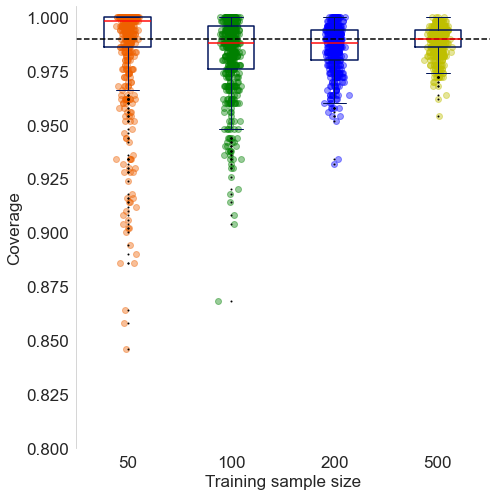

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3661114990.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


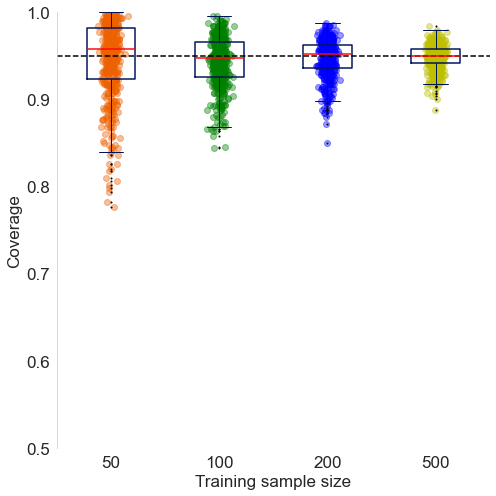

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3661114990.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


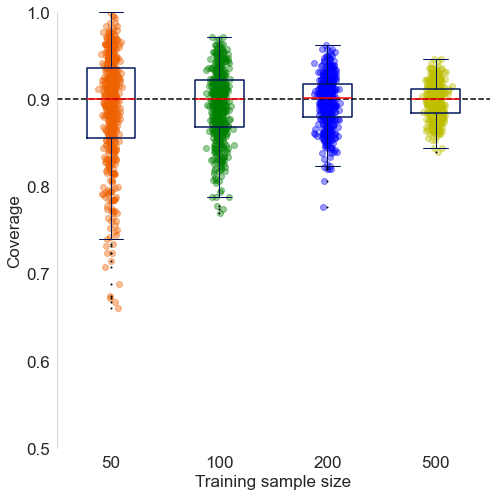

In [56]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1.005)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_50_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [150]:
iv_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

iv_pb_coverage_df_kappa_200_alpha_01['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['IV_coverage'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_200_alpha_05['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['IV_coverage'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_200_alpha_1['IV_coverage']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['IV_coverage'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_200_alpha_01.head()
iv_pb_coverage_df_kappa_200_alpha_05.head()
iv_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,forest,time,II_coverage,IV_coverage
1,452,100,200,0.179382,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.97, 0.946, 0.832]",0.952
2,440,500,200,0.170186,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.994, 0.952, 0.898]",0.904
9,90,500,200,0.171167,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.992, 0.974, 0.918]",0.874
11,35,100,200,0.193350,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[1.0, 0.932, 0.882]",0.958
12,173,500,200,0.153221,"BaggedRegressor(bootstrap_fraction=1, bootstra...",NaN,"[0.986, 0.94, 0.888]",0.864


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3563971696.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


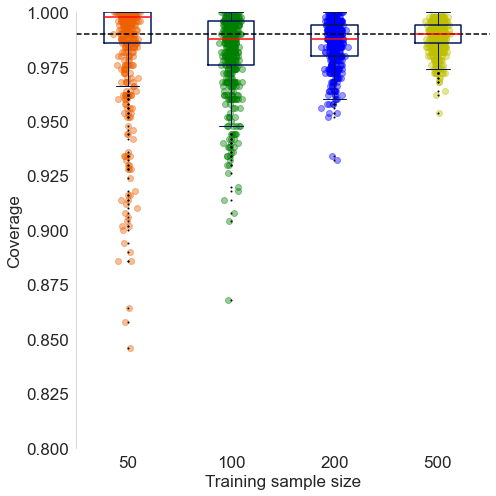

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3563971696.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


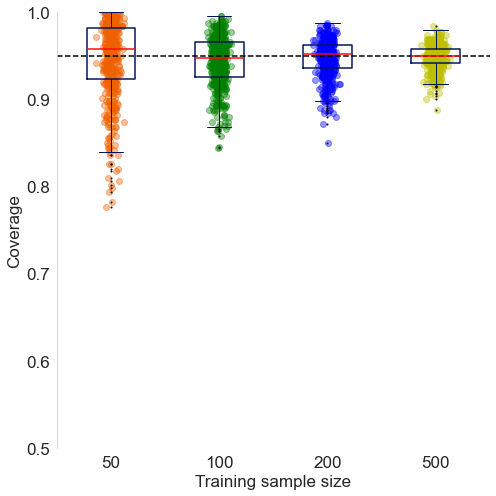

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_33670/3563971696.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


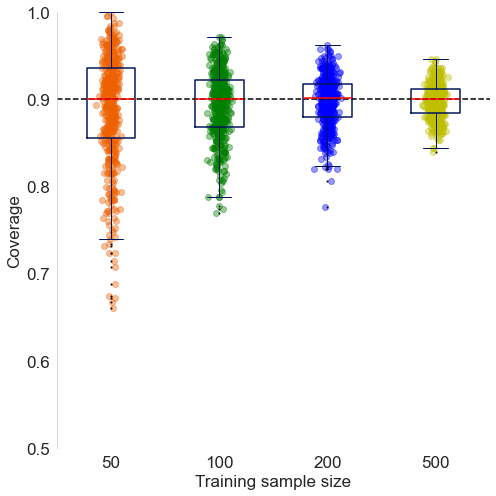

In [58]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values,
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    if alpha_level == 0.01:
        ax.set_ylim(0.8, 1)
    else:
        ax.set_ylim(0.5, 1)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_200_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

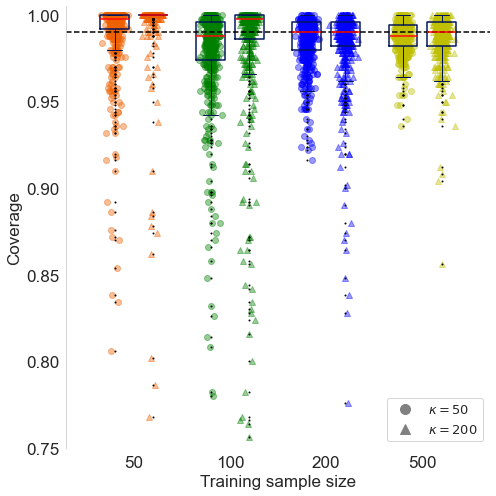

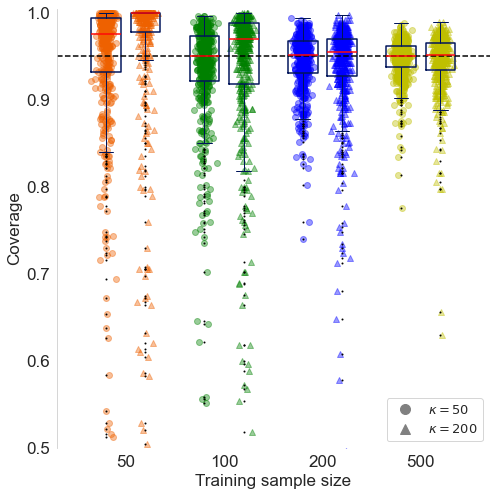

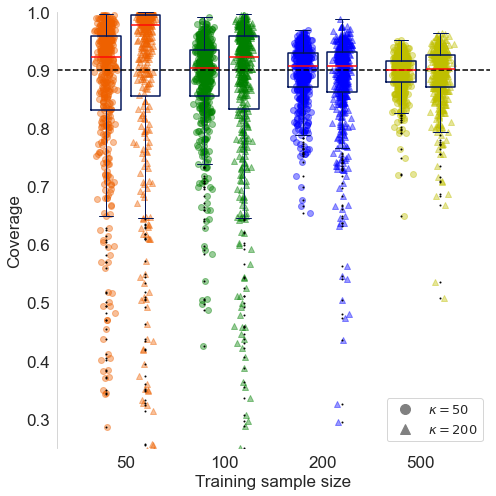

In [158]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, kappa_200_data, alpha_level in zip(
    [iv_pb_coverage_df_kappa_50_alpha_01, iv_pb_coverage_df_kappa_50_alpha_05, iv_pb_coverage_df_kappa_50_alpha_1], 
    [iv_pb_coverage_df_kappa_200_alpha_01, iv_pb_coverage_df_kappa_200_alpha_05, iv_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.75, 1.005)
    elif alpha_level == 0.05:
        ax.set_ylim(0.5, 1.005)
    else:
        ax.set_ylim(0.25, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_sphere/pb_kappa_50_200_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()